# Chapitre 3 — Prétraitement des mammographies

**🎯 Objectif :** transformer les DICOM bruts (téléchargés au ch1) en PNG **2944×1920** prêts pour GMIC, via 5 étapes : DICOM→PNG 16-bit, fichier PKL, recadrage du fond noir, resize+uint8, flip des vues droites.
**⏱ Durée :** échantillon ~1–2 min (proportionnel au nombre d'images). Entrée : `data/in/…`, sortie : `data/work/…`. Le temps total est affiché à la fin.

Une mammographie brute ne peut pas être envoyée telle quelle à GMIC : il attend des images de **taille fixe** (2944×1920), **sans le fond noir** autour du sein, dans une **plage d'intensité** précise. Cinq étapes transforment l'image brute en ce format.

**Tout le pipeline est écrit dans ce notebook** (seul le recadrage appelle le script original de GMIC). Un **unique curseur** (`DATASET`, section suivante) choisit le jeu de données ; entrée et sortie en découlent. Il n'y a donc rien d'autre à régler : exécute de haut en bas.

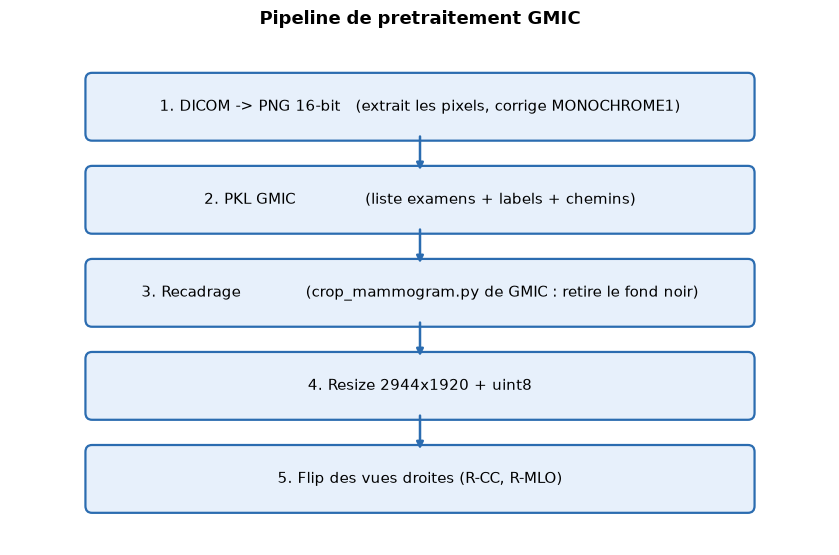

In [1]:
import os, sys, glob, csv, pickle, shutil, zipfile, subprocess
from multiprocessing import Pool
import cv2, numpy as np, pydicom
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from course_utils import flowchart, gmic_dir, data_in, preprocess_dir

GMIC_DIR = gmic_dir()                           # sous-module modules/GMIC
if GMIC_DIR not in sys.path:
    sys.path.insert(0, GMIC_DIR)
GMIC_H, GMIC_W = 2944, 1920                     # taille d'entrée attendue par GMIC
VIEWS = ('L-CC', 'L-MLO', 'R-CC', 'R-MLO')

flowchart([
    '1. DICOM -> PNG 16-bit   (extrait les pixels, corrige MONOCHROME1)',
    '2. PKL GMIC              (liste examens + labels + chemins)',
    '3. Recadrage             (crop_mammogram.py de GMIC : retire le fond noir)',
    '4. Resize 2944x1920 + uint8',
    '5. Flip des vues droites (R-CC, R-MLO)',
], title='Pipeline de pretraitement GMIC')

## Quel jeu de données prétraiter ?

**Un seul curseur pour tout le cours** : `DATASET`. Il désigne ce que le ch1 a téléchargé,
et il détermine à lui seul l'entrée *et* la sortie :

| `DATASET` | Entrée (ch1) | Sortie (ce notebook) |
|---|---|---|
| `'rsna_sample'` | `data/in/rsna_sample` — les quelques images de la **section A** | `data/work/preprocess_sample` |
| `'rsna'` | `data/in/rsna` — tout le dataset RSNA (**section B**) | `data/work/preprocess_image` |

Le chemin de sortie n'est **pas** écrit à la main ici : il vient de `preprocess_dir(DATASET)`,
dans [`course_utils.py`](course_utils.py). Les chapitres suivants (ch4 et l'chapitre 5) lisent
avec **le même appel et le même curseur** — écrivain et lecteurs ne peuvent donc pas pointer
vers deux dossiers différents, qui était exactement le piège à éviter.

Le dossier d'entrée doit contenir `train_images/<patient>/<image>.dcm` et un `train.csv`.
La sortie va dans `data/work/` (séparation stricte entrée brute / résultats produits).

In [4]:
# ────────────────────────────────────────────────────────────────────────────
DATASET = 'rsna_sample'      # <── LE CURSEUR : 'rsna_sample' (démo, ch1 section A)
#                                   ou 'rsna' (dataset complet, ch1 section B).
#                                   Le ch4 et l'chapitre 5 utilisent LE MÊME nom.
# ────────────────────────────────────────────────────────────────────────────
INPUT_DIR  = data_in(DATASET)          # images à prétraiter (train_images/<pid>/<iid>.dcm + train.csv)
OUTPUT_DIR = preprocess_dir(DATASET)   # PNG prétraités + .pkl — chemin défini dans course_utils
CSV_PATH   = os.path.join(INPUT_DIR, 'train.csv')        # labels (patient / vue / cancer)
NUM_PROC   = 4                                           # cœurs pour la parallélisation

RAW_DIR     = os.path.join(INPUT_DIR, 'train_images')
PNG_DIR     = os.path.join(OUTPUT_DIR, 'png_images')
CROPPED_DIR = os.path.join(OUTPUT_DIR, 'cropped_images')
# Deux PKL, pas trois : le crop de GMIC (étape 3) lit une liste et en écrit une autre
# (un exécutable ne peut pas réécrire son fichier d'entrée en le lisant). Sa sortie EST
# déjà la liste finale — le flip de l'étape 5 ne touche que les pixels, pas la liste —
# donc on lui fait écrire directement data.pkl, sans copie intermédiaire.
PKL_RAW     = os.path.join(OUTPUT_DIR, 'exam_list_before_cropping.pkl')  # entrée du crop
PKL_FINAL   = os.path.join(OUTPUT_DIR, 'data.pkl')                       # sortie du crop = fichier final
# Témoin de l'étape 5 : le flip est la SEULE étape non rejouable (reflipper = remettre à
# l'endroit). Ce fichier dit « ces PNG sont déjà retournés » et rend la cellule sûre à
# ré-exécuter seule. L'étape 3, qui régénère des PNG non retournés, l'efface.
FLIP_MARKER = os.path.join(OUTPUT_DIR, '.flip_done')
os.makedirs(PNG_DIR, exist_ok=True)

import time
_t_pre = time.time()   # chrono du prétraitement complet (total affiché à la dernière étape)

print('Jeu de données :', DATASET)
print('Entrée :', INPUT_DIR)
print('Sortie :', OUTPUT_DIR, '| processus:', NUM_PROC)
assert os.path.isdir(RAW_DIR), (
    f"{RAW_DIR} introuvable — vérifie DATASET ci-dessus, "
    f"ou exécute d'abord 01_download_data.ipynb.")

Jeu de données : rsna_sample
Entrée : /home/deep-piste/course/data/in/rsna_sample
Sortie : /home/deep-piste/course/data/work/preprocess_sample | processus: 4


## Étape 1 — DICOM → PNG 16-bit

Les mammographies sont stockées en **DICOM** (`.dcm`), un format qui encapsule bien
plus que l'image (identité patient, paramètres scanner...). On en extrait les pixels
bruts vers des PNG 16-bit.

Piège classique : certains scanners stockent les niveaux **inversés**
(`PhotometricInterpretation == 'MONOCHROME1'`) — sans correction, le tissu mammaire
serait blanc sur fond noir, l'inverse de ce qu'attend GMIC.

In [5]:
def dicom_to_png16(task):
    """Convertit 1 DICOM en PNG 16-bit (MONOCHROME1 inversé, normalisation [0, 65535])."""
    pid, iid = task
    out = os.path.join(PNG_DIR, pid, f'{iid}.png')
    if os.path.exists(out):
        return 'skip'
    # Kaggle sert les DICOM soit bruts, soit zippés (`.dcm.zip`) selon les images : on gère les 2.
    zip_path = os.path.join(RAW_DIR, pid, f'{iid}.dcm.zip')
    dcm_path = os.path.join(RAW_DIR, pid, f'{iid}.dcm')
    try:
        if os.path.exists(zip_path):
            with zipfile.ZipFile(zip_path) as z:
                name = next(n for n in z.namelist() if n.endswith('.dcm'))
                with z.open(name) as fh:
                    ds = pydicom.dcmread(fh)
        elif os.path.exists(dcm_path):
            ds = pydicom.dcmread(dcm_path)
        else:
            return 'missing'
        arr = ds.pixel_array.astype(np.float32)
        if ds.PhotometricInterpretation == 'MONOCHROME1':
            arr = arr.max() - arr                      # inverse : blanc <-> noir
        m = arr.max()
        # Étire vers toute la plage 16-bit : les DICOM RSNA n'utilisent que ~12 bits utiles
        # (valeurs jusqu'à ~4095) ; les stocker tels quels sous-exploiterait l'espace uint16
        # et donnerait un PNG très sombre à l'affichage.
        arr = (arr / m * 65535).astype(np.uint16) if m > 0 else arr.astype(np.uint16)
        os.makedirs(os.path.join(PNG_DIR, pid), exist_ok=True)
        cv2.imwrite(out, arr)
        return 'ok'
    except Exception as e:
        return f'err:{e}'

with open(CSV_PATH) as f:
    tasks = sorted({(r['patient_id'], r['image_id']) for r in csv.DictReader(f)})

# imap + tqdm : barre de progression sur la conversion parallèle.
# Pool marche ici bien que dicom_to_png16 soit défini DANS le notebook : sous Linux, les
# processus enfants sont FORKÉS (copie mémoire du parent, pas de ré-import du module) —
# sous Windows/macOS (spawn), cette fonction ne serait pas picklable et Pool échouerait.
with Pool(NUM_PROC) as pool:
    res = list(tqdm(pool.imap(dicom_to_png16, tasks), total=len(tasks), desc='Étape 1 DICOM→PNG'))
print('Étape 1 — convertis:', res.count('ok'), '| déjà OK:', res.count('skip'),
      '| manquants/erreurs:', sum(1 for r in res if r not in ('ok', 'skip')))

Étape 1 DICOM→PNG:   0%|          | 0/36 [00:00<?, ?it/s]

Étape 1 — convertis: 36 | déjà OK: 0 | manquants/erreurs: 0


## Étape 2 — Le fichier PKL GMIC

GMIC n'accède pas aux images directement : il lit un **`.pkl`** qui décrit chaque
examen — chemins des 4 vues (L-CC, L-MLO, R-CC, R-MLO), labels (`cancer_label`) et
métadonnées. On le construit depuis `train.csv`.

Convention RSNA des labels : `malignant` = sein avec cancer biopsié ; `benign` =
biopsié **sans** cancer. Un sein jamais biopsié reste NI l'un NI l'autre (ne pas
étiqueter ~98 % des seins sains comme « benign »).

In [6]:
def build_exam_pkl(csv_path, png_dir, pkl_path):
    patients = {}
    with open(csv_path) as f:
        for r in csv.DictReader(f):
            pid = r['patient_id']
            patients.setdefault(pid, {
                # Champ du schéma GMIC natif : piloterait un flip A LA VOLÉE au chargement.
                # Ici on flip les pixels nous-mêmes à l'étape 5 (une fois, sur disque) donc
                # ce flag reste toujours 'NO' — gardé pour la compatibilité du schéma PKL.
                'horizontal_flip': 'NO',
                'L-CC': [], 'L-MLO': [], 'R-CC': [], 'R-MLO': [],
                'cancer_label': {'benign': 0, 'left_benign': 0, 'right_benign': 0,
                                 'malignant': 0, 'left_malignant': 0,
                                 'right_malignant': 0, 'unknown': 0},
            })
            iid, lat, view = r['image_id'], r['laterality'], r['view']
            if not os.path.exists(os.path.join(png_dir, pid, f'{iid}.png')):
                continue
            vk = f'{lat}-{view}'
            if vk in patients[pid]:
                patients[pid][vk].append(f'{pid}/{iid}')
            side = 'left' if lat == 'L' else 'right'
            if int(r['cancer']) == 1:
                patients[pid]['cancer_label']['malignant'] = 1
                patients[pid]['cancer_label'][f'{side}_malignant'] = 1
            if int(r['biopsy']) == 1 and int(r['cancer']) == 0:
                patients[pid]['cancer_label']['benign'] = 1
                patients[pid]['cancer_label'][f'{side}_benign'] = 1
    exam_list = [e for e in patients.values() if any(e[v] for v in VIEWS)]
    with open(pkl_path, 'wb') as f:
        pickle.dump(exam_list, f)
    return exam_list

exams = build_exam_pkl(CSV_PATH, PNG_DIR, PKL_RAW)
print('Étape 2 — examens:', len(exams),
      '| dont cancer:', sum(1 for e in exams if e['cancer_label']['malignant']))

Étape 2 — examens: 8 | dont cancer: 1


## Étape 3 — Recadrage (supprimer le fond noir)

Une mammographie brute contient beaucoup de **fond noir**. GMIC, entraîné sur des
images recadrées, est moins performant si on le garde.

On appelle ici le script **original de GMIC** `src/cropping/crop_mammogram.py` en
sous-processus (érosion → plus grande composante connexe → dilatation → bounding box).
C'est volontaire : on réutilise exactement la logique des auteurs du papier, plutôt
que de la réimplémenter. C'est aussi lui qui écrit la `window_location` dans le PKL.

In [7]:
if os.path.exists(CROPPED_DIR):
    shutil.rmtree(CROPPED_DIR)
# Les PNG qu'on va régénérer sortiront du crop NON retournés : le témoin de l'étape 5 ne
# décrit plus la réalité, on l'efface. Sans ça, un 2e passage sauterait le flip et laisserait
# les vues droites dans le mauvais sens.
if os.path.exists(FLIP_MARKER):
    os.remove(FLIP_MARKER)

cmd = [sys.executable, 'src/cropping/crop_mammogram.py',
       '--input-data-folder', PNG_DIR,
       '--output-data-folder', CROPPED_DIR,
       '--exam-list-path', PKL_RAW,
       '--cropped-exam-list-path', PKL_FINAL,   # écrit directement data.pkl (liste + window_location)
       '--num-processes', str(NUM_PROC)]
# cwd=GMIC_DIR : le script est référencé en chemin RELATIF (src/cropping/...) et ses propres
# imports internes (`from src...`) supposent qu'on l'exécute depuis la racine du repo GMIC.
# PYTHONPATH : même raison côté import Python (le sous-processus doit retrouver le package `src`).
env = dict(os.environ, PYTHONPATH=GMIC_DIR + os.pathsep + os.environ.get('PYTHONPATH', ''))
res = subprocess.run(cmd, cwd=GMIC_DIR, env=env, stderr=subprocess.PIPE)
if res.returncode != 0:
    raise RuntimeError('crop_mammogram a échoué :\n' + res.stderr.decode()[-800:])
print('Étape 3 — images recadrées:',
      len(glob.glob(os.path.join(CROPPED_DIR, '**', '*.png'), recursive=True)))

Étape 3 — images recadrées: 36


## Étape 4 — Resize 2944×1920 + uint8

Après recadrage les images ont des tailles variables (selon le scanner). GMIC ayant
été entraîné en **2944×1920**, on redimensionne tout à cette taille puis on ramène en
**uint8** [0, 255].

**Deux interpolations** : `INTER_AREA` pour **réduire** (moyenne les pixels, évite
l'aliasing), `INTER_LINEAR` pour **agrandir** (bilinéaire, plus doux).

> Le pipeline de recherche met aussi à jour, dans le PKL, les coordonnées du crop
> (`rightmost_points`, etc.) à la nouvelle échelle — utile à l'inférence GMIC. On
> l'omet ici : ce notebook s'arrête aux images prêtes + `data.pkl`.

In [8]:
def normalize_uint8(img):
    f = img.astype(np.float32); lo, hi = f.min(), f.max()
    return ((f - lo) / (hi - lo) * 255).astype(np.uint8) if hi > lo else np.zeros_like(f, np.uint8)

def resize_one(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return 'none'
    h, w = img.shape[:2]
    if (h, w) != (GMIC_H, GMIC_W):
        interp = cv2.INTER_AREA if (h > GMIC_H or w > GMIC_W) else cv2.INTER_LINEAR
        img = cv2.resize(img, (GMIC_W, GMIC_H), interpolation=interp)
    if img.dtype != np.uint8 or img.max() > 255:
        img = normalize_uint8(img)
    cv2.imwrite(path, img)
    return 'ok'

cropped_pngs = glob.glob(os.path.join(CROPPED_DIR, '**', '*.png'), recursive=True)
with Pool(NUM_PROC) as pool:
    res = list(tqdm(pool.imap(resize_one, cropped_pngs), total=len(cropped_pngs), desc='Étape 4 resize'))
print('Étape 4 —', res.count('ok'), f'images en {GMIC_W}x{GMIC_H} uint8')

Étape 4 resize:   0%|          | 0/36 [00:00<?, ?it/s]

Étape 4 — 36 images en 1920x2944 uint8


## Étape 5 — Flip horizontal des vues droites

GMIC a été entraîné avec **tous les seins orientés à gauche**. Les vues droites
(R-CC, R-MLO) sont naturellement orientées à droite : on les retourne une fois ici,
pour que toutes les images stockées soient déjà dans l'orientation attendue.

Ce flip ne modifie que **les pixels** : la liste d'examens décrite par `data.pkl`
(déjà écrite par le recadrage à l'étape 3) reste inchangée — c'est notre fichier final,
celui qu'on passerait à l'inférence.

> ⚠️ **La seule étape non rejouable du pipeline.** Un flip est sa propre inverse : le
> rejouer remettrait les vues droites dans le mauvais sens, sans aucun message d'erreur.
> D'où le témoin `.flip_done` écrit à la fin — la cellule devient sûre à ré-exécuter
> seule, et l'étape 3 efface ce témoin quand elle régénère des images non retournées.

> La **normalisation mean/std** (z-score), elle, reste appliquée *à la volée* au
> chargement : elle produit des float négatifs, incompatibles avec un PNG uint8.

In [9]:
def flip_one(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return 0
    cv2.imwrite(path, cv2.flip(img, 1))           # 1 = axe vertical = flip horizontal
    return 1

# Garde-fou d'idempotence. Un flip est sa propre inverse : le rejouer remet les vues droites
# dans le mauvais sens, SANS erreur ni message — corruption silencieuse. Le témoin écrit en
# fin de cellule rend donc cette cellule sûre à ré-exécuter seule (l'étape 3 l'efface quand
# elle régénère des PNG non retournés).
if os.path.exists(FLIP_MARKER):
    print('Étape 5 — déjà fait (témoin .flip_done présent) : rien à retourner.')
    print('          Pour tout refaire proprement, rejoue depuis l étape 3.')
else:
    # On relit data.pkl (écrit par le crop à l'étape 3) juste pour LISTER les vues droites à
    # retourner. Le flip agit sur les pixels des PNG, pas sur la liste : data.pkl reste valable
    # tel quel, rien à réécrire.
    with open(PKL_FINAL, 'rb') as f:
        exam_list = pickle.load(f)
    right_paths = [os.path.join(CROPPED_DIR, sfp + '.png')
                   for e in exam_list for v in ('R-CC', 'R-MLO')
                   for sfp in e.get(v, [])
                   if os.path.exists(os.path.join(CROPPED_DIR, sfp + '.png'))]
    with Pool(NUM_PROC) as pool:
        flipped = sum(tqdm(pool.imap(flip_one, right_paths), total=len(right_paths), desc='Étape 5 flip'))
    # Témoin écrit APRÈS le flip : si la cellule plante en cours de route, il est absent et
    # l'étape sera rejouée — mieux qu'un état « à moitié retourné » déclaré terminé.
    open(FLIP_MARKER, 'w').close()
    print('Étape 5 — vues droites retournées:', flipped, '| fichier final :', PKL_FINAL)

Étape 5 flip:   0%|          | 0/18 [00:00<?, ?it/s]

Étape 5 — vues droites retournées: 18 | fichier final : /home/deep-piste/course/data/work/preprocess_sample/data.pkl


## Résultat

Chaque vue est désormais un PNG **2944×1920 uint8**, fond noir retiré, vues droites
alignées — directement exploitable par GMIC (chapitres 4 et 5). Vérifions sur une
vraie image.

✅ 36 images prêtes pour GMIC — ex. (2944, 1920) uint8.
⏱ Prétraitement total (5 étapes) : 157.5 s pour 36 images.


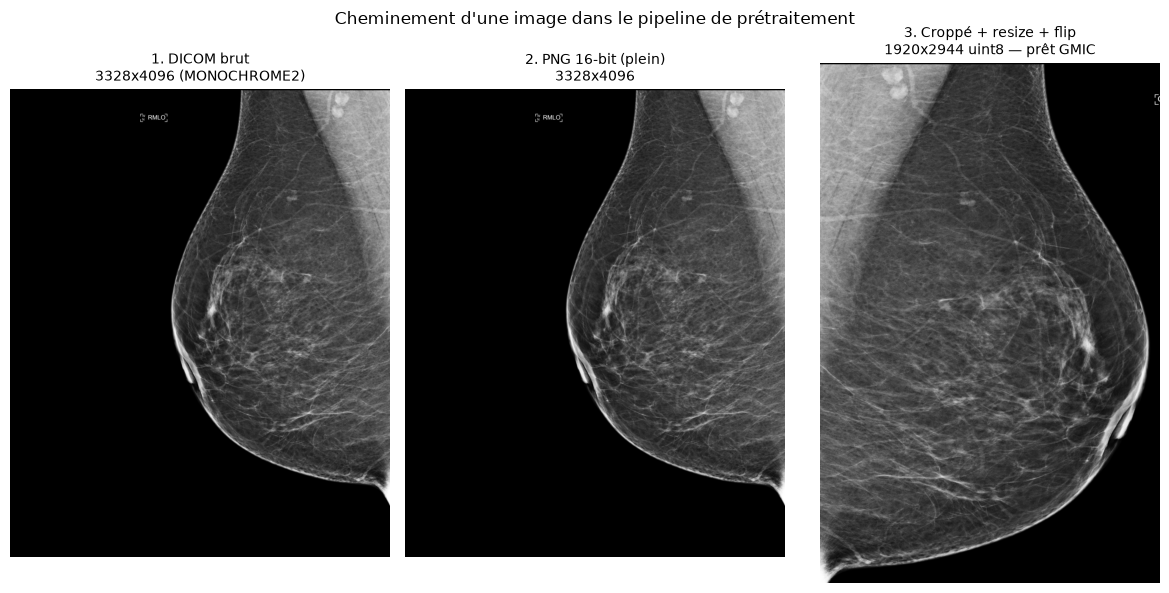

In [10]:
out_pngs = sorted(glob.glob(os.path.join(CROPPED_DIR, '**', '*.png'), recursive=True))
final = cv2.imread(out_pngs[0], cv2.IMREAD_UNCHANGED)
assert final.shape == (GMIC_H, GMIC_W) and final.dtype == np.uint8
print(f'✅ {len(out_pngs)} images prêtes pour GMIC — ex. {final.shape} {final.dtype}.')
print(f'⏱ Prétraitement total (5 étapes) : {time.time() - _t_pre:.1f} s pour {len(out_pngs)} images.')

# --- Cheminement d'UNE image à travers le pipeline ---
rel = os.path.relpath(out_pngs[0], CROPPED_DIR)                       # <pid>/<iid>.png
png16 = cv2.imread(os.path.join(PNG_DIR, rel), cv2.IMREAD_UNCHANGED)  # après étape 1 (DICOM->PNG16)

# On relit le DICOM brut correspondant (avant tout traitement) pour la 1re vignette.
pid = os.path.dirname(rel)
iid = os.path.splitext(os.path.basename(rel))[0]
zip_path = os.path.join(RAW_DIR, pid, f'{iid}.dcm.zip')
dcm_path = os.path.join(RAW_DIR, pid, f'{iid}.dcm')
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        with z.open(next(n for n in z.namelist() if n.endswith('.dcm'))) as fh:
            ds = pydicom.dcmread(fh)
else:
    ds = pydicom.dcmread(dcm_path)
raw = ds.pixel_array.astype(np.float32)
if ds.PhotometricInterpretation == 'MONOCHROME1':
    raw = raw.max() - raw

stages = [
    (raw,   f'1. DICOM brut\n{raw.shape[1]}x{raw.shape[0]} ({ds.PhotometricInterpretation})'),
    (png16, f'2. PNG 16-bit (plein)\n{png16.shape[1]}x{png16.shape[0]}'),
    (final, f'3. Croppé + resize + flip\n{final.shape[1]}x{final.shape[0]} uint8 — prêt GMIC'),
]
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
for a, (im, title) in zip(ax, stages):
    a.imshow(im, cmap='gray'); a.axis('off'); a.set_title(title, fontsize=10)
fig.suptitle("Cheminement d'une image dans le pipeline de prétraitement", fontsize=12)
plt.tight_layout(); plt.show()